# Day 15 — Correlation
### #30DayChartChallenge | April 2026

**Environmental Stress vs Life Expectancy.** A composite environmental stress score (PM2.5 air pollution + unsafe water + poor sanitation) correlated with life expectancy for 190 countries. r = -0.83 — multiple environmental factors combine to reduce lifespan.

**Data:** World Bank (2020) — EN.ATM.PM25.MC.M3, SH.H2O.BASW.ZS, SH.STA.BASS.ZS, SP.DYN.LE00.IN  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(ggrepel)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: World Bank API (2020)
# EN.ATM.PM25.MC.M3 — PM2.5 air pollution (ug/m3)
# SH.H2O.BASW.ZS — % using basic drinking water
# SH.STA.BASS.ZS — % using basic sanitation
# SP.DYN.LE00.IN — Life expectancy at birth
# Composite stress = mean(normalized PM2.5, % no water, % no sanitation)

df <- read.csv("../../data/day_15/env_stress_life_expectancy.csv",
               stringsAsFactors = FALSE)

r <- cor(df$env_stress, df$life_exp, use = "complete.obs")
cat("Correlation:", round(r, 3), "\n")
cat("Countries:", nrow(df), "\n")

Correlation: -0.827 
Countries: 190 


`geom_smooth()` using formula = 'y ~ x'


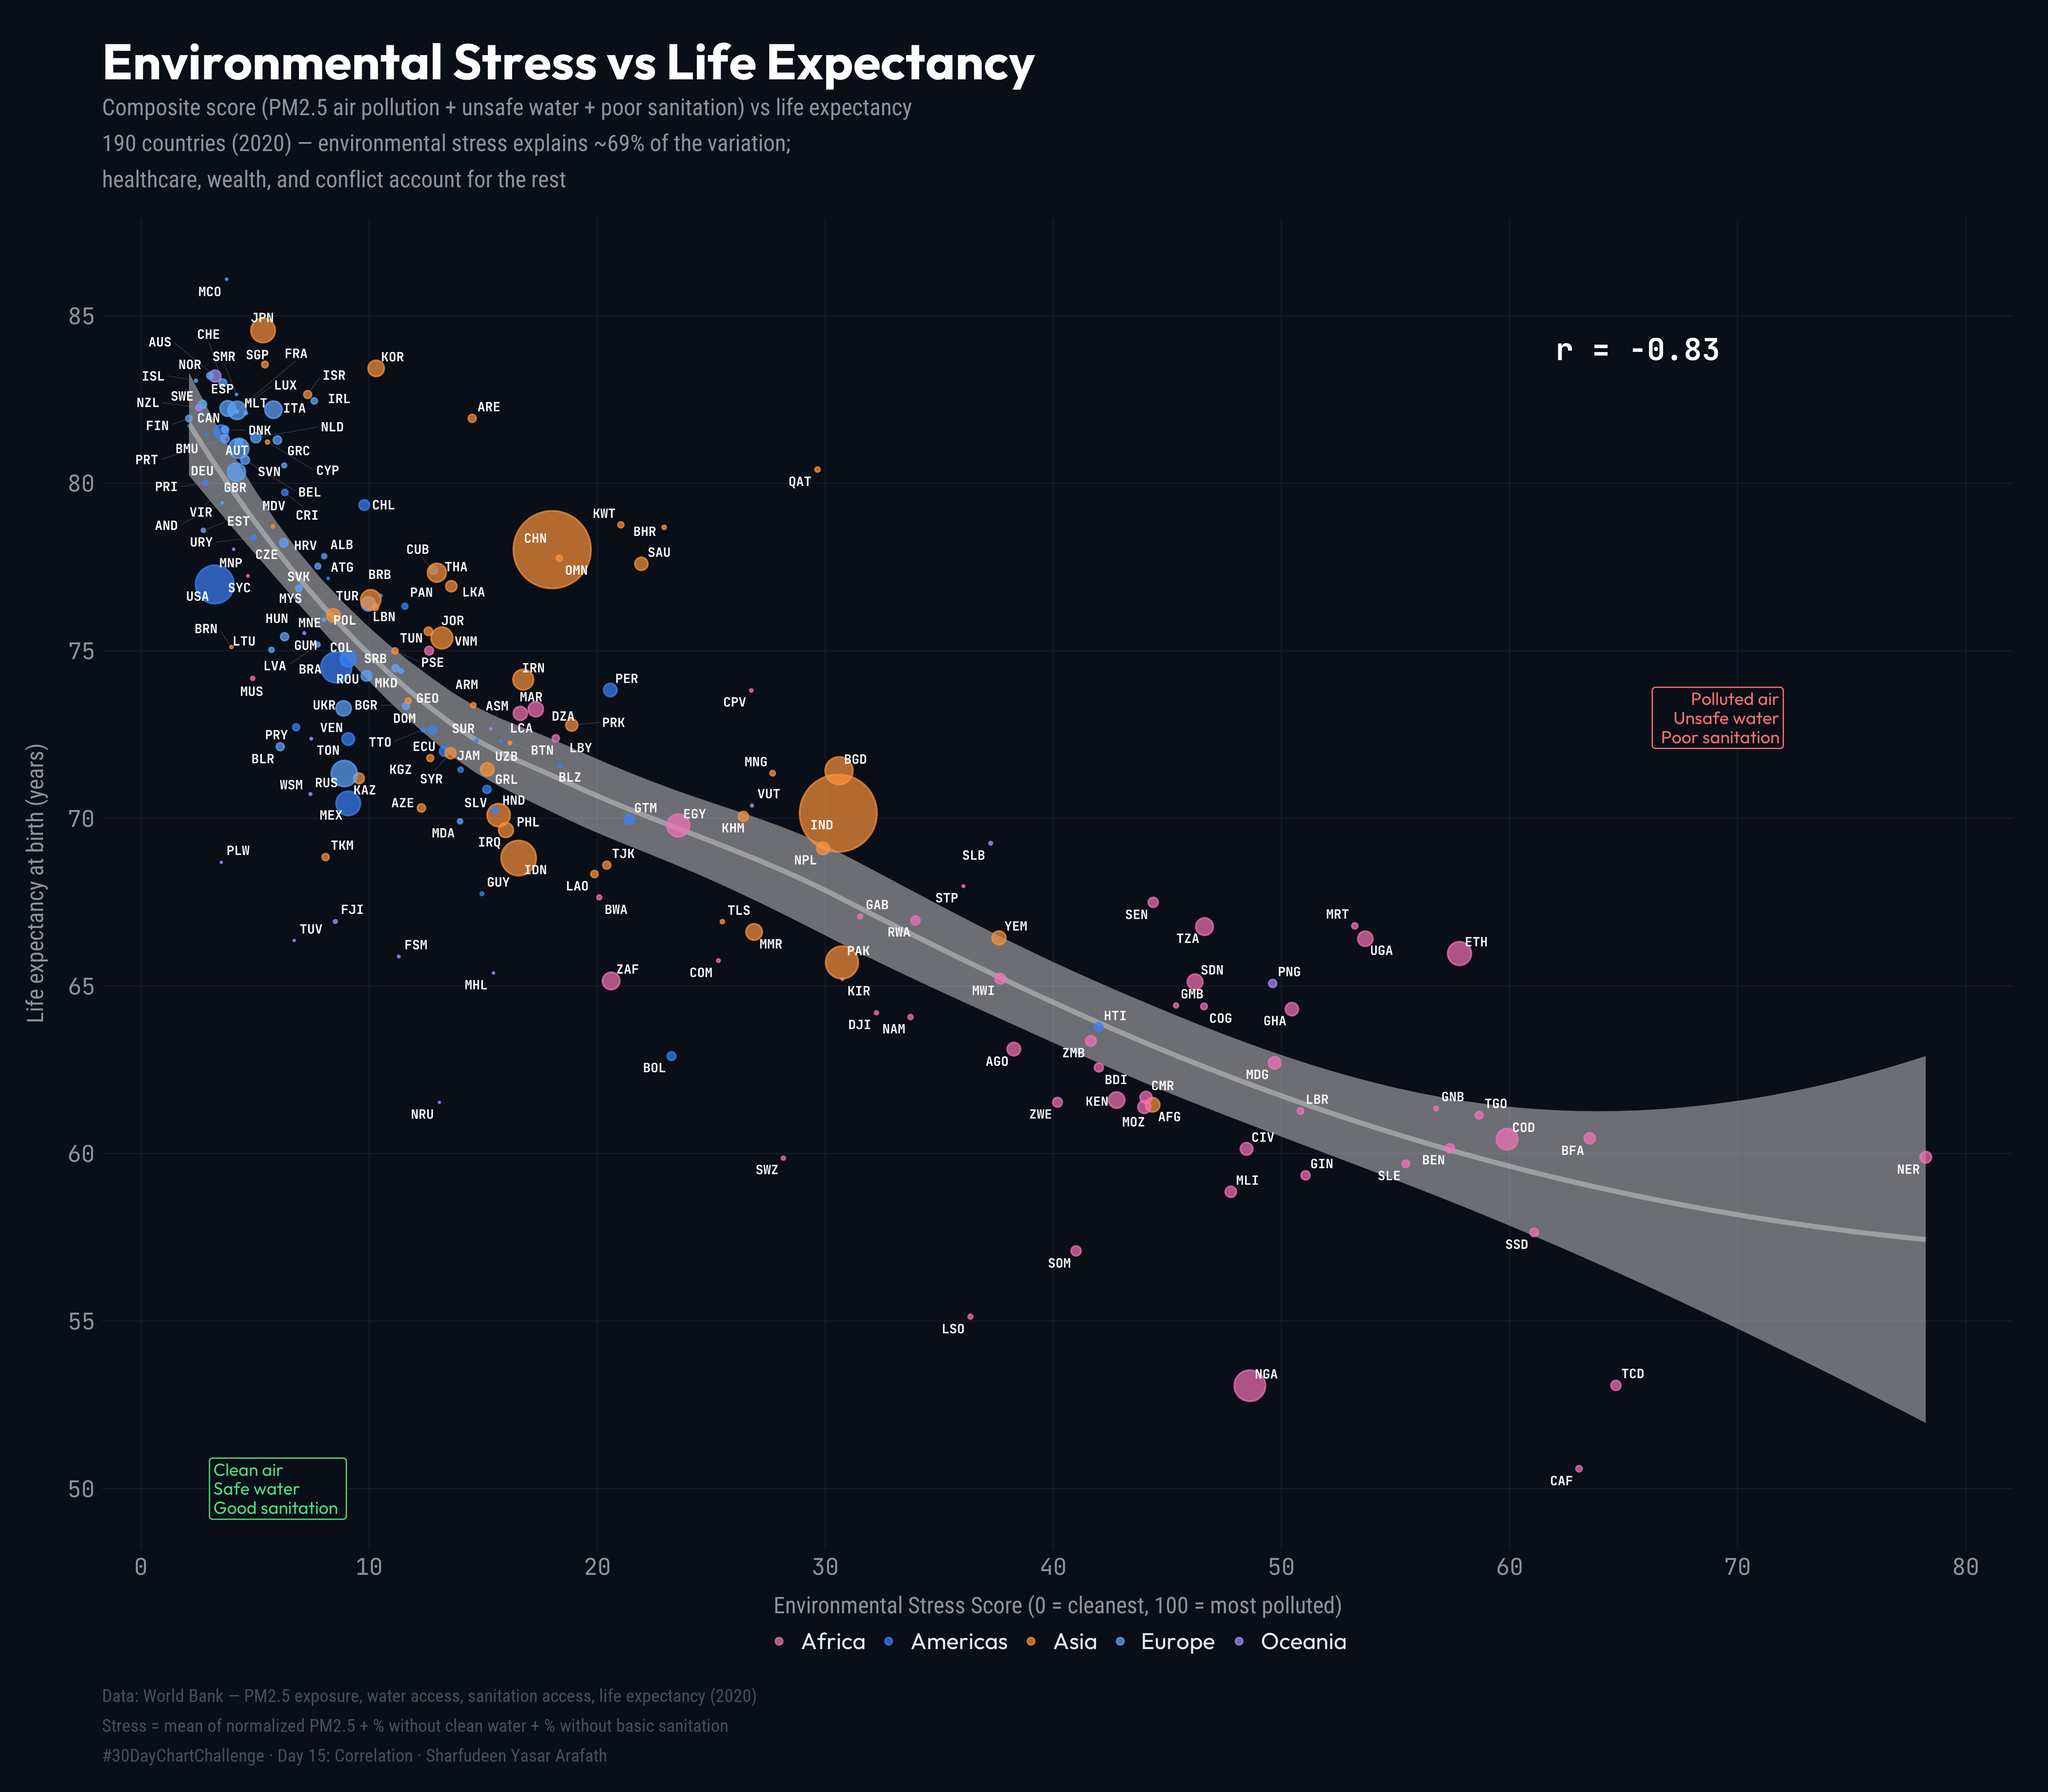

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

cont_colors <- c(
  "Africa" = "#F472B6", "Americas" = "#3B82F6",
  "Asia" = "#FB923C", "Europe" = "#60A5FA", "Oceania" = "#A78BFA"
)

p <- ggplot(df, aes(x = env_stress, y = life_exp)) +

  geom_smooth(method = "loess", se = TRUE, color = "#FFFFFF55",
    fill = "#FFFFFF08", linewidth = 1, span = 0.8) +

  geom_point(aes(size = population, color = continent), alpha = 0.7) +

  # All country labels in WHITE
  geom_text_repel(aes(label = iso3),
    family = "jetbrains", size = 2.5, fontface = "bold",
    color = "#FFFFFF",
    segment.color = txt_dim, segment.size = 0.15, segment.alpha = 0.3,
    max.overlaps = 100, box.padding = 0.2, point.padding = 0.15,
    force = 1.5, seed = 42) +

  annotate("text", x = 62, y = 84,
    label = paste0("r = ", round(r, 2)),
    family = "jetbrains", size = 6, color = "#FFFFFF",
    fontface = "bold", hjust = 0) +

  annotate("label", x = 3, y = 50,
    label = "Clean air\nSafe water\nGood sanitation",
    family = "outfit", size = 3.5, color = "#4ade80",
    fill = "#0a0e17CC", hjust = 0, lineheight = 0.9) +

  annotate("label", x = 72, y = 73,
    label = "Polluted air\nUnsafe water\nPoor sanitation",
    family = "outfit", size = 3.5, color = "#f87171",
    fill = "#0a0e17CC", hjust = 1, lineheight = 0.9) +

  scale_x_continuous(breaks = seq(0, 80, 10)) +
  scale_y_continuous(breaks = seq(50, 85, 5)) +
  scale_size_area(max_size = 20, guide = "none") +
  scale_color_manual(values = cont_colors) +

  labs(
    title = "Environmental Stress vs Life Expectancy",
    subtitle = paste0(
      "Composite score (PM2.5 air pollution + unsafe water + poor sanitation) vs life expectancy\n",
      "190 countries (2020) \u2014 environmental stress explains ~69% of the variation;\n",
      "healthcare, wealth, and conflict account for the rest"
    ),
    x = "Environmental Stress Score (0 = cleanest, 100 = most polluted)",
    y = "Life expectancy at birth (years)",
    color = NULL,
    caption = paste0(
      "Data: World Bank \u2014 PM2.5 exposure, water access, sanitation access, life expectancy (2020)\n",
      "Stress = mean of normalized PM2.5 + % without clean water + % without basic sanitation\n",
      "#30DayChartChallenge \u00b7 Day 15: Correlation \u00b7 Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 28,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 13, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 10, hjust = 0, color = txt_cap,
      lineheight = 1.4, margin = margin(t = 15)),
    axis.text = element_text(size = 13, color = txt_dim, family = "jetbrains"),
    axis.title = element_text(size = 13, color = txt_dim),
    axis.title.y = element_text(margin = margin(r = 10)),
    axis.title.x = element_text(margin = margin(t = 10)),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.text = element_text(size = 13, color = txt, family = "outfit"),
    legend.key.size = unit(0.5, "cm"),
    legend.margin = margin(t = -5, b = 5),
    panel.grid.major = element_line(color = grid_col, linewidth = 0.15),
    panel.grid.minor = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 20, 15, 15)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_15_correlation.png",
       plot = p, width = 16, height = 14, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_15_correlation.png\n")

`geom_smooth()` using formula = 'y ~ x'


Done — saved to chart/day_15_correlation.png
